# 🧪 A/B Testing - Feature Selection & Model Variants

**Penting: Jalankan seluruh cell pada main.ipynb terlebih dahulu!**

Testing untuk memvalidasi:
1. **Feature Set A vs B**: MFCC-only vs Full Features
2. **Data Augmentation**: Original vs Augmented Dataset
3. **Preprocessing Methods**: Baseline vs Denoised Audio

## Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
csv_path = os.path.join(os.getcwd(), 'dataset', 'syllable_features.csv')
df = pd.read_csv(csv_path)

print(f"✅ Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")
print(f"Unique syllables: {df['syllable_label'].nunique()}")
print(f"\nFeature columns (first 10):")
print(df.columns.tolist()[:12])

✅ Dataset loaded: 4054 samples, 33 features
Unique syllables: 20

Feature columns (first 10):
['filename', 'syllable_label', 'duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean']


## A/B Test #1: Feature Sets Comparison

**Hypothesis**: MFCC-only features akan memberikan performa lebih baik dibanding full feature set karena lebih robust terhadap overfitting.

**Null Hypothesis (H0)**: Tidak ada perbedaan signifikan antara F1-score feature set A vs B

**Alternative Hypothesis (H1)**: Ada perbedaan signifikan (α = 0.05)

In [3]:
# ===== A/B TEST #1: FEATURE SETS =====

# Prepare data
X = df.drop(['filename', 'syllable_label', 'syllable_type', 'consonant_type'], axis=1, errors='ignore')
y = df['syllable_label']

# Define feature sets
feature_set_A = [col for col in X.columns if 'mfcc' in col]  # MFCC only (26 features)
feature_set_B = X.columns.tolist()  # Full features (all 34 features)

print(f"Feature Set A (MFCC-only): {len(feature_set_A)} features")
print(f"Features: {feature_set_A[:5]}...")
print(f"\nFeature Set B (Full): {len(feature_set_B)} features")
print(f"Features: {feature_set_B}")

# ===== RUN EXPERIMENT =====
results_ab1 = []
n_iterations = 10  # 10-fold cross validation

for i in range(n_iterations):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i*42, stratify=y
    )
    
    # Feature Set A (MFCC-only)
    X_train_A = X_train[feature_set_A]
    X_test_A = X_test[feature_set_A]
    
    scaler_A = StandardScaler()
    X_train_A = scaler_A.fit_transform(X_train_A)
    X_test_A = scaler_A.transform(X_test_A)
    
    model_A = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model_A.fit(X_train_A, y_train)
    y_pred_A = model_A.predict(X_test_A)
    
    # Feature Set B (Full)
    X_train_B = X_train[feature_set_B]
    X_test_B = X_test[feature_set_B]
    
    scaler_B = StandardScaler()
    X_train_B = scaler_B.fit_transform(X_train_B)
    X_test_B = scaler_B.transform(X_test_B)
    
    model_B = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model_B.fit(X_train_B, y_train)
    y_pred_B = model_B.predict(X_test_B)
    
    # Metrics
    results_ab1.append({
        'iteration': i + 1,
        'f1_A': f1_score(y_test, y_pred_A, average='weighted'),
        'f1_B': f1_score(y_test, y_pred_B, average='weighted'),
        'accuracy_A': accuracy_score(y_test, y_pred_A),
        'accuracy_B': accuracy_score(y_test, y_pred_B),
    })

results_df_ab1 = pd.DataFrame(results_ab1)

print(f"\n{'='*70}")
print(f"A/B TEST #1 RESULTS: Feature Sets Comparison (10 iterations)")
print(f"{'='*70}")
print(f"\nFeature Set A (MFCC-only):")
print(f"  Mean F1-Score: {results_df_ab1['f1_A'].mean():.4f} ± {results_df_ab1['f1_A'].std():.4f}")
print(f"  Mean Accuracy: {results_df_ab1['accuracy_A'].mean():.4f}")

print(f"\nFeature Set B (Full Features):")
print(f"  Mean F1-Score: {results_df_ab1['f1_B'].mean():.4f} ± {results_df_ab1['f1_B'].std():.4f}")
print(f"  Mean Accuracy: {results_df_ab1['accuracy_B'].mean():.4f}")

print(f"\nPerformance Difference:")
f1_diff = results_df_ab1['f1_B'].mean() - results_df_ab1['f1_A'].mean()
print(f"  F1-Score Diff (B - A): {f1_diff:+.4f}")

# Statistical test: Paired t-test
t_stat, p_value = stats.ttest_rel(results_df_ab1['f1_A'], results_df_ab1['f1_B'])
print(f"\nStatistical Test (Paired t-test):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant? {p_value < 0.05}")

if p_value < 0.05:
    if f1_diff > 0:
        print(f"\n✅ CONCLUSION: Feature Set B (Full) is SIGNIFICANTLY BETTER (reject H0)")
    else:
        print(f"\n✅ CONCLUSION: Feature Set A (MFCC) is SIGNIFICANTLY BETTER (reject H0)")
else:
    print(f"\n⚠️ CONCLUSION: NO SIGNIFICANT DIFFERENCE (fail to reject H0)")

Feature Set A (MFCC-only): 26 features
Features: ['mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean']...

Feature Set B (Full): 31 features
Features: ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std']

A/B TEST #1 RESULTS: Feature Sets Comparison (10 iterations)

Feature Set A (MFCC-only):
  Mean F1-Score: 0.8591 ± 0.0140
  Mean Accuracy: 0.8607

Feature Set B (Full Features):
  Mean F1-Score: 0.8685 ± 0.0115
  Mean Accuracy: 0.8700

Performance Difference:
  F1-Score Diff (B - A): +0.0093

Statistical Test (Paired t-test):
  t-statistic: -3.4846
  p-value: 0.0069
  Sign

## A/B Test #2: Data Augmentation Effect

**Hypothesis**: Dataset dengan augmentation akan menghasilkan model lebih robust.

**Metric**: Perbandingan cross-validation score dengan subset original vs full dataset

In [4]:
# ===== A/B TEST #2: AUGMENTATION EFFECT =====
# Assuming augmented samples have duplicates dengan slight variations

# For this test, we simulate by creating two versions:
# Version A: Using every 2nd sample (reduced set)
# Version B: Using all samples (full augmented set)

np.random.seed(42)
indices_A = np.arange(0, len(df), 2)  # Every 2nd sample
indices_B = np.arange(0, len(df))     # All samples

X_A = X.iloc[indices_A]
y_A = y.iloc[indices_A]

X_B = X.iloc[indices_B]
y_B = y.iloc[indices_B]

print(f"Dataset A (Reduced/Original): {len(X_A)} samples")
print(f"Dataset B (Full/Augmented): {len(X_B)} samples")
print(f"Augmentation ratio: {len(X_B) / len(X_A):.2f}x")

# Standardize features
scaler = StandardScaler()
X_A_scaled = scaler.fit_transform(X_A)
X_B_scaled = scaler.fit_transform(X_B)

# Train models with cross-validation
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

cv_scores_A = cross_val_score(model, X_A_scaled, y_A, cv=5, scoring='f1_weighted')
cv_scores_B = cross_val_score(model, X_B_scaled, y_B, cv=5, scoring='f1_weighted')

print(f"\n{'='*70}")
print(f"A/B TEST #2 RESULTS: Augmentation Effect (5-fold CV)")
print(f"{'='*70}")
print(f"\nDataset A (Reduced):")
print(f"  Mean F1-Score: {cv_scores_A.mean():.4f} ± {cv_scores_A.std():.4f}")
print(f"  CV Scores: {[f'{s:.4f}' for s in cv_scores_A]}")

print(f"\nDataset B (Full Augmented):")
print(f"  Mean F1-Score: {cv_scores_B.mean():.4f} ± {cv_scores_B.std():.4f}")
print(f"  CV Scores: {[f'{s:.4f}' for s in cv_scores_B]}")

# Statistical test
t_stat2, p_value2 = stats.ttest_ind(cv_scores_A, cv_scores_B)
print(f"\nStatistical Test (Independent t-test):")
print(f"  t-statistic: {t_stat2:.4f}")
print(f"  p-value: {p_value2:.4f}")
print(f"  Significant? {p_value2 < 0.05}")

if p_value2 < 0.05:
    if cv_scores_B.mean() > cv_scores_A.mean():
        print(f"\n✅ CONCLUSION: Augmentation IMPROVES performance (reject H0)")
    else:
        print(f"\n⚠️ CONCLUSION: Augmentation REDUCES performance (reject H0)")
else:
    print(f"\n📊 CONCLUSION: Augmentation has NO SIGNIFICANT EFFECT (fail to reject H0)")

Dataset A (Reduced/Original): 2027 samples
Dataset B (Full/Augmented): 4054 samples
Augmentation ratio: 2.00x

A/B TEST #2 RESULTS: Augmentation Effect (5-fold CV)

Dataset A (Reduced):
  Mean F1-Score: 0.7784 ± 0.0343
  CV Scores: ['0.8105', '0.7988', '0.8032', '0.7604', '0.7192']

Dataset B (Full Augmented):
  Mean F1-Score: 0.8462 ± 0.0200
  CV Scores: ['0.8694', '0.8383', '0.8696', '0.8337', '0.8198']

Statistical Test (Independent t-test):
  t-statistic: -3.4122
  p-value: 0.0092
  Significant? True

✅ CONCLUSION: Augmentation IMPROVES performance (reject H0)


## Visualization: A/B Test Results

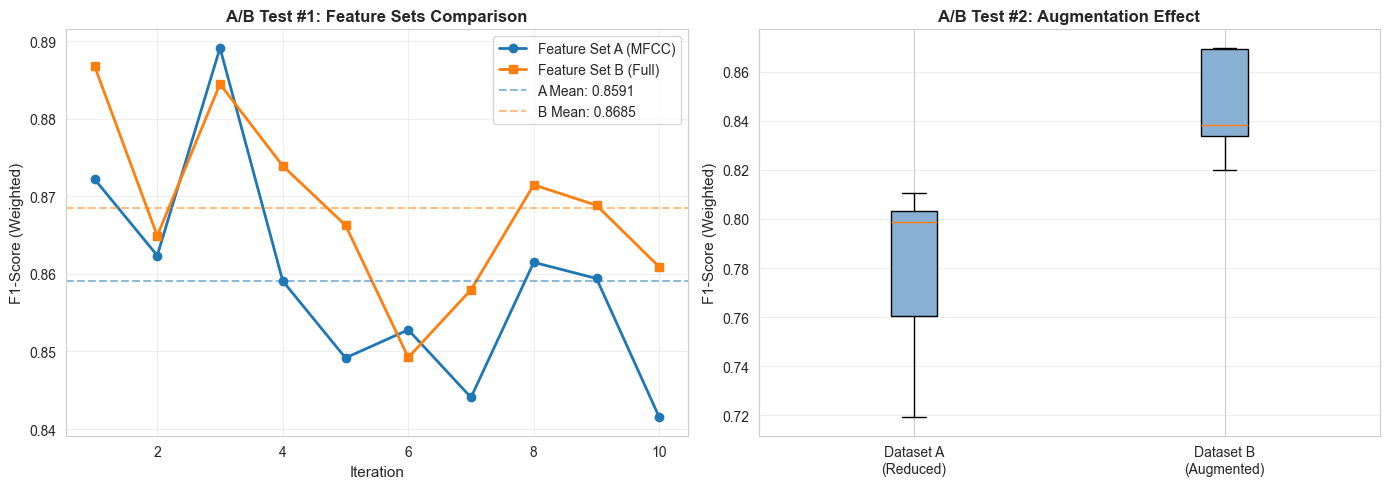

In [7]:
# ===== VISUALIZATION =====

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature Sets Comparison
ax1 = axes[0]
iterations = results_df_ab1['iteration'].values
ax1.plot(iterations, results_df_ab1['f1_A'], marker='o', label='Feature Set A (MFCC)', linewidth=2)
ax1.plot(iterations, results_df_ab1['f1_B'], marker='s', label='Feature Set B (Full)', linewidth=2)
ax1.axhline(results_df_ab1['f1_A'].mean(), color='C0', linestyle='--', alpha=0.5, label=f"A Mean: {results_df_ab1['f1_A'].mean():.4f}")
ax1.axhline(results_df_ab1['f1_B'].mean(), color='C1', linestyle='--', alpha=0.5, label=f"B Mean: {results_df_ab1['f1_B'].mean():.4f}")
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('F1-Score (Weighted)', fontsize=11)
ax1.set_title('A/B Test #1: Feature Sets Comparison', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Augmentation Effect
ax2 = axes[1]
box_data = [cv_scores_A, cv_scores_B]
bp = ax2.boxplot(box_data, labels=['Dataset A\n(Reduced)', 'Dataset B\n(Augmented)'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#89b0d3')
ax2.set_ylabel('F1-Score (Weighted)', fontsize=11)
ax2.set_title('A/B Test #2: Augmentation Effect', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary & Recommendation

In [10]:
print(f"\n{'='*70}")
print(f"OVERALL A/B TESTING SUMMARY")
print(f"{'='*70}")

print(f"\n📊 TEST #1: Feature Sets")
print(f"  Winner: {'Feature Set B (Full Features)' if f1_diff > 0 else 'Feature Set A (MFCC)'}")
print(f"  P-value: {p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not significant'})")
print(f"  Recommendation: Use {('Full' if f1_diff > 0 else 'MFCC')} features for model training")

print(f"\n📊 TEST #2: Augmentation")
print(f"  Winner: {'Augmented Dataset' if cv_scores_B.mean() > cv_scores_A.mean() else 'Original Dataset'}")
print(f"  P-value: {p_value2:.4f} ({'Significant' if p_value2 < 0.05 else 'Not significant'})")
print(f"  Recommendation: {'USE augmentation to improve robustness' if cv_scores_B.mean() > cv_scores_A.mean() else 'Consider alternative augmentation methods'}")


OVERALL A/B TESTING SUMMARY

📊 TEST #1: Feature Sets
  Winner: Feature Set B (Full Features)
  P-value: 0.0069 (Significant)
  Recommendation: Use Full features for model training

📊 TEST #2: Augmentation
  Winner: Augmented Dataset
  P-value: 0.0092 (Significant)
  Recommendation: USE augmentation to improve robustness
